Gerekli Kütüphaneler

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

Veri Oluşturma (Sentetik Gözlem)

In [28]:
# Gerçek değerler (Doğa tarafından biliniyor, bizim tarafımızdan değil)
true_mu = 150.0 # Gerçek parlaklık
true_sigma = 10.0 # Gözlem hatası
n_obs = 50 # Gözlem sayısı
# Gürültülü veri oluşturma
np.random.seed(42)
data = true_mu + true_sigma *np.random.randn(n_obs)

Bayesyen Fonksiyonların Tanımlanması

In [29]:
# 1. Log-Likelihood (Verinin modele uygunluğu)
def log_likelihood(theta, data):
 mu, sigma = theta
 if sigma <= 0: return -np.inf # Fiziksel olmayan durum
 return -0.5 * np.sum(((data - mu) / sigma)**2 + np.log(2 * np.pi * sigma**2))
# 2. Log-Prior (Parametreler hakkındaki ön bilgilerimiz)
def log_prior(theta):
 mu, sigma = theta
 if 0 < mu < 300 and 0 < sigma < 50: # Geniş ve informatif olmayan bir sınır
    return 0.0
 return -np.inf
# 3. Log-Posterior (Hedef fonksiyonumuz)
def log_probability(theta, data):
 lp = log_prior(theta)
 if not np.isfinite(lp):
    return -np.inf
 return lp + log_likelihood(theta, data)

MCMC Örnekleyiciyi Çalıştırma

In [30]:
# Başlangıç değerleri
initial = [140, 5]
n_walkers = 32
pos = initial + 1e-4 * np.random.randn(n_walkers, 2)
sampler = emcee.EnsembleSampler(n_walkers, 2, log_probability,
args=(data,))
sampler.run_mcmc(pos, 2000, progress=True)
# Örnekleri toplama (ilk 500 adımı 'burn-in' olarak atıyoruz)
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

100%|██████████| 2000/2000 [00:01<00:00, 1204.26it/s]


Sonuçların Görselleştirilmesi ve Yorumlanması

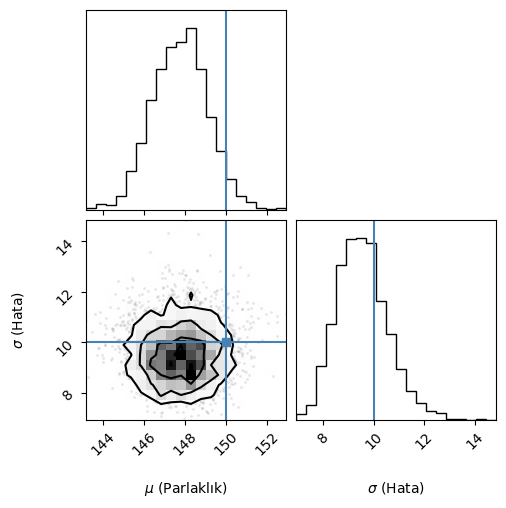

In [31]:
fig = corner.corner(
 flat_samples, labels=["$\mu$ (Parlaklık)", "$\sigma$ (Hata)"],
 truths=[true_mu, true_sigma]
)
plt.show()

In [32]:
# Mu (Parlaklık) Hesaplamaları
mu_yuzdelikler = np.percentile(flat_samples[:, 0], [16, 50, 84])
mu_mutlak_hata = np.abs(true_mu - mu_yuzdelikler[1])

# Sigma (Hata Payı) Hesaplamaları
sigma_yuzdelikler = np.percentile(flat_samples[:, 1], [16, 50, 84])
sigma_mutlak_hata = np.abs(true_sigma - sigma_yuzdelikler[1])

# Tablo için çıktıları yazdırma
print("--- MU (Parlaklık) İÇİN TABLO DEĞERLERİ ---")
print(f"Tahmin Edilen (Median): {mu_yuzdelikler[1]:.2f}")
print(f"Alt Sınır (%16):        {mu_yuzdelikler[0]:.2f}")
print(f"Üst Sınır (%84):        {mu_yuzdelikler[2]:.2f}")
print(f"Mutlak Hata:            {mu_mutlak_hata:.2f}\n")

print("--- SIGMA (Hata Payı) İÇİN TABLO DEĞERLERİ ---")
print(f"Tahmin Edilen (Median): {sigma_yuzdelikler[1]:.2f}")
print(f"Alt Sınır (%16):        {sigma_yuzdelikler[0]:.2f}")
print(f"Üst Sınır (%84):        {sigma_yuzdelikler[2]:.2f}")
print(f"Mutlak Hata:            {sigma_mutlak_hata:.2f}")

--- MU (Parlaklık) İÇİN TABLO DEĞERLERİ ---
Tahmin Edilen (Median): 147.79
Alt Sınır (%16):        146.43
Üst Sınır (%84):        149.07
Mutlak Hata:            2.21

--- SIGMA (Hata Payı) İÇİN TABLO DEĞERLERİ ---
Tahmin Edilen (Median): 9.49
Alt Sınır (%16):        8.55
Üst Sınır (%84):        10.53
Mutlak Hata:            0.51
